<a href="https://colab.research.google.com/github/farrelrassya/time-series-forecasting-in-python/blob/main/Chapter_18_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 18 — Deep-Learning Capstone: Forecasting Household Electric Power Consumption

*Based on "Time Series Forecasting in Python" by Marco Peixeiro, Chapter 18.*

This is the **second capstone of the book**. Chapter 11 brought together everything from the statistical-forecasting half (Ch 4–10) to forecast Australian antidiabetic-drug prescriptions; this chapter does the analogous job for the deep-learning half (Ch 12–17), applying the entire toolkit — `DataWindow`, `compile_and_fit`, baselines, linear, dense, LSTM, CNN, CNN+LSTM hybrid, and **autoregressive LSTM (ARLSTM)** — to a new, larger, harder dataset.

**The dataset.** Minute-by-minute electrical-power readings from a single household in Sceaux, France, recorded between **December 2006 and November 2010** — roughly 47 months and over **2 million data points**. Released by UC Irvine ML Repository. After cleaning and resampling to hourly granularity we obtain $\sim 35{,}000$ rows — almost **3× larger** than the traffic-volume dataset used in Ch 13–17.

**The objective.** Build a **univariate multi-step** model that forecasts `Global_active_power` (the real power consumed by the household, in kilowatts) for the **next 24 hours** given the last 24 hours of observations. The economic stakes are real: utilities need accurate consumption forecasts to balance grid load, schedule generation capacity, and avoid both undersupply (blackouts) and oversupply (grid instability).

**The architectures we'll train (seven trained models + two baselines):**

| Rung | Model | What it tests |
|---|---|---|
| 0 | Baseline - Last value | Floor: tomorrow looks like the last hour |
| 0 | Baseline - Repeat day | Floor: tomorrow looks like today |
| 1 | Linear | One Dense layer — does data have linear signal? |
| 2 | Dense | Two-layer ReLU MLP — does it have *nonlinear* signal? |
| 3 | LSTM | Recurrent — does temporal structure help? |
| 4 | CNN | Convolutional — does local-feature filtering help? |
| 5 | CNN + LSTM | Hybrid — best of both worlds? |
| 6 | **ARLSTM** | Autoregressive feedback — does iterative forecasting win? |

The ARLSTM is the **new architecture** for this chapter (introduced in Ch 17). Unlike all other multi-step models which produce 24 predictions in one forward pass, the ARLSTM generates one prediction at a time and **feeds its own output back as the next input** — mirroring how SARIMA forecasts roll forward. The hypothesis: this autoregressive structure should give the best multi-step forecasts on this dataset.

**Why a capstone matters.** The book's chapter-by-chapter narrative isolated each architectural change. A capstone integrates them: it shows whether the lessons transfer to a fundamentally different problem (electricity consumption vs traffic volume), and forces the student to compare **eight** models on a single page of bar charts. The dataset is large enough that overfitting is a real risk, and the daily seasonality is more subtle than the highly periodic traffic pattern — both factors that stress-test our toolkit.

## Data preparation — summary of Section 18.2–18.3

The book's Section 18.2 walks through the cleaning steps from the raw 2-million-row text file. We summarize the work and download the **already-cleaned, scaled, and split** datasets from the book's GitHub for direct use:

**Steps the book applied to the raw data:**

1. **Dropped `Sub_metering_3`** — $25{,}979$ missing values ($\sim 1.25\%$ of rows) with a single consecutive gap of **$7{,}226$ minutes** ($\approx 5$ days). Imputing such a long gap would inject a fabricated trend, so the column is removed entirely.
2. **Converted columns 3–9 to numeric** with `pd.to_numeric(errors='coerce')`. The raw text file stored every value as a string.
3. **Combined `Date` + `Time` → single datetime column.**
4. **Resampled from minute → hourly** by taking the hourly sum. Minute-level data is too noisy and operationally pointless (the grid cannot rebalance within minutes anyway). Hourly sums are smoother and more forecastable.
5. **Dropped the first and last hours** (incomplete hours of $35$ and $2$ minutes respectively, leaving partial sums) — final shape $34{,}949 \times 6$.
6. **Dropped `Sub_metering_1`** during feature engineering — the basic statistics showed it has value $0$ for $75\%$ of rows, so it carries no signal about variations in the target.
7. **Cyclic time encoding** — created `day_sin` and `day_cos` so $23:00$ and $00:00$ are treated as adjacent on a unit circle. This step requires confirming **daily seasonality is real**; the book uses an FFT and finds a clear peak at frequency $1/24\text{h}$ and no peak at $1/(7 \cdot 24\text{h})$ — daily yes, weekly no.
8. **70/20/10 train/val/test split** on the chronologically-ordered data (no shuffling at this stage).
9. **MinMax scaling** fitted **only on the training set**, then applied to all three sets. This prevents information leakage from validation/test into the scaler's fitted range.

The final shapes: **train $(24{,}464, 7)$, val $(6{,}990, 7)$, test $(3{,}495, 7)$**. The 7 columns are: `Global_active_power` (target), `Global_reactive_power`, `Voltage`, `Global_intensity`, `Sub_metering_2`, `day_sin`, `day_cos`.

Below we load these pre-processed CSVs directly.

## Setup

Same TensorFlow / Keras imports as Ch 13–17. New imports this chapter: `RNN` and `LSTMCell` (needed for the autoregressive LSTM, which we build by manually stepping the LSTM cell forward).

In [1]:
# Install required packages (Colab already has tensorflow)
!pip install -q tensorflow pandas numpy matplotlib

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError
from tensorflow.keras.layers import Dense, Conv1D, LSTM, RNN, LSTMCell

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 7.5)
plt.rcParams['axes.grid'] = False

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow version :', tf.__version__)

TensorFlow version : 2.20.0


TF 2.21.0 confirmed. New imports for this chapter:

- **`RNN`** — Keras's generic recurrent-layer wrapper. We feed it an `LSTMCell` to build a single recurrent layer, which we'll then unroll manually for autoregressive prediction.
- **`LSTMCell`** — the *single-step* LSTM computation (vs the `LSTM` layer which applies the cell over a whole sequence at once). For autoregressive prediction we need to step forward one timestep at a time, so we'll call the cell directly.

In [2]:
# Download pre-processed datasets from the book's GitHub
import urllib.request
base_url = 'https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/master/data'

for fname in ['ch18_train.csv', 'ch18_val.csv', 'ch18_test.csv']:
    urllib.request.urlretrieve(f'{base_url}/{fname}', fname)

train_df = pd.read_csv('ch18_train.csv')
val_df   = pd.read_csv('ch18_val.csv')
test_df  = pd.read_csv('ch18_test.csv')

print(f'Train shape: {train_df.shape}')
print(f'Val shape:   {val_df.shape}')
print(f'Test shape:  {test_df.shape}')
print(f'\nColumns: {list(train_df.columns)}')
train_df.head()

Train shape: (24464, 7)
Val shape:   (6990, 7)
Test shape:  (3495, 7)

Columns: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_2', 'day_sin', 'day_cos']


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_2,day_sin,day_cos
0,0.553644,0.103358,0.934691,0.549618,0.144652,0.370590,0.982963
1,0.518286,0.110073,0.929321,0.510981,0.030869,0.500000,1.000000
2,0.498217,0.096987,0.932664,0.490311,0.000000,0.629410,0.982963
3,0.465887,0.099010,0.944965,0.459659,0.008973,0.750000,0.933013
4,0.335359,0.072536,0.951346,0.335526,0.002872,0.853553,0.853553


The three pre-processed sets load as **$(24{,}464, 7)$, $(6{,}990, 7)$, $(3{,}495, 7)$** — matching the book's reported shapes exactly. Every value is in $[0, 1]$ thanks to the MinMax scaling.

**Reading the feature columns:**

- `Global_active_power` — **the target**: real power consumed by the household (kW)
- `Global_reactive_power` — power that oscillates between source and load without doing useful work (kW)
- `Voltage` — line voltage (V)
- `Global_intensity` — current intensity (A)
- `Sub_metering_2` — energy used in the laundry room (washing machine, dryer, refrigerator, light — Wh)
- `day_sin`, `day_cos` — cyclic encoding of hour-of-day

**Why no weather columns?** The dataset doesn't include temperature, humidity, or solar irradiance. In a production setting, weather data would almost certainly help — hot summer days drive AC usage, cold winter days drive heating. The book notes this gap explicitly and recommends augmenting with weather data in a real project. We work with what's available.

In [3]:
# Dictionary of column name -> index. Needed for label_columns
# and baseline-class label_index parameters.
column_indices = {name: i for i, name in enumerate(train_df.columns)}
print('Column indices:', column_indices)

Column indices: {'Global_active_power': 0, 'Global_reactive_power': 1, 'Voltage': 2, 'Global_intensity': 3, 'Sub_metering_2': 4, 'day_sin': 5, 'day_cos': 6}


`Global_active_power` is at index $0$ — important for the baseline classes which need to know which column of the input to use as the prediction.

## The forecasting infrastructure — `DataWindow` and `compile_and_fit`

These classes have been our companions for six chapters now. We reload them verbatim. **The one change**: the default `plot_col` argument is `'Global_active_power'` instead of `'traffic_volume'`, so plots default to showing the new target.

In [4]:
class DataWindow():
    def __init__(self, input_width, label_width, shift,
                 train_df=train_df, val_df=val_df, test_df=test_df,
                 label_columns=None):
        self.train_df = train_df
        self.val_df   = val_df
        self.test_df  = test_df

        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_indices = {name: i for i, name in enumerate(label_columns)}
        self.column_indices = {name: i for i, name in enumerate(train_df.columns)}

        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift
        self.total_window_size = input_width + shift

        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]

        self.label_start = self.total_window_size - self.label_width
        self.labels_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

    def split_to_inputs_labels(self, features):
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.labels_slice, :]
        if self.label_columns is not None:
            labels = tf.stack(
                [labels[:, :, self.column_indices[name]] for name in self.label_columns],
                axis=-1
            )
        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])
        return inputs, labels

    def plot(self, model=None, plot_col='Global_active_power', max_subplots=3):
        inputs, labels = self.sample_batch
        plt.figure(figsize=(12, 8))
        plot_col_index = self.column_indices[plot_col]
        max_n = min(max_subplots, len(inputs))
        for n in range(max_n):
            plt.subplot(max_n, 1, n + 1)
            plt.ylabel(f'{plot_col} [scaled]')
            plt.plot(self.input_indices, inputs[n, :, plot_col_index],
                     label='Inputs', marker='.', zorder=-10)
            if self.label_columns:
                label_col_index = self.label_columns_indices.get(plot_col, None)
            else:
                label_col_index = plot_col_index
            if label_col_index is None:
                continue
            plt.scatter(self.label_indices, labels[n, :, label_col_index],
                        edgecolors='k', marker='s', label='Labels', c='green', s=64)
            if model is not None:
                predictions = model(inputs)
                plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                            marker='X', edgecolors='k', label='Predictions', c='red', s=64)
            if n == 0:
                plt.legend()
        plt.xlabel('Time (h)')

    def make_dataset(self, data):
        data = np.array(data, dtype=np.float32)
        ds = tf.keras.preprocessing.timeseries_dataset_from_array(
            data=data, targets=None,
            sequence_length=self.total_window_size, sequence_stride=1,
            shuffle=True, batch_size=32
        )
        return ds.map(self.split_to_inputs_labels)

    @property
    def train(self): return self.make_dataset(self.train_df)
    @property
    def val(self):   return self.make_dataset(self.val_df)
    @property
    def test(self):  return self.make_dataset(self.test_df)

    @property
    def sample_batch(self):
        result = getattr(self, '_sample_batch', None)
        if result is None:
            result = next(iter(self.train))
            self._sample_batch = result
        return result


def compile_and_fit(model, window, patience=3, max_epochs=50):
    early_stopping = EarlyStopping(monitor='val_loss', patience=patience, mode='min')
    model.compile(loss=MeanSquaredError(), optimizer=Adam(),
                  metrics=[MeanAbsoluteError()])
    return model.fit(window.train, epochs=max_epochs,
                     validation_data=window.val,
                     callbacks=[early_stopping], verbose=0)


# Create the multi-step window we'll use for ALL non-CNN models
multi_window = DataWindow(input_width=24, label_width=24, shift=24,
                          label_columns=['Global_active_power'])

print('DataWindow class + compile_and_fit ready.')
print(f'multi_window: input_width=24, label_width=24, shift=24, total_window={multi_window.total_window_size}')

DataWindow class + compile_and_fit ready.
multi_window: input_width=24, label_width=24, shift=24, total_window=48


**The window geometry is the same across this entire chapter:**

- **Input width $= 24$** — the model sees the previous 24 hours.
- **Label width $= 24$** — it must produce 24 hourly predictions.
- **Shift $= 24$** — labels start 24 hours *after* the input ends; this is genuine 24-hour-ahead forecasting with no overlap.
- **Total window $= 48$**.

The CNN-based models will need a slightly wider input window ($26$ hours) to accommodate the $3$-wide kernel without padding. We'll define that window when we get to the CNN section.

## Stage 0: Baseline models

Two baselines, exactly the same classes we've used since Ch 13:

1. **`MultiStepLastBaseline`** — predict the last hour's value, held flat for 24 hours. Naive in the extreme.
2. **`RepeatBaseline`** — predict the previous 24 hours as the next 24 hours. Equivalent to "tomorrow looks like today" — the natural baseline for daily-seasonal data.

In [5]:
class MultiStepLastBaseline(Model):
    def __init__(self, label_index=None):
        super().__init__()
        self.label_index = label_index

    def call(self, inputs):
        if self.label_index is None:
            return tf.tile(inputs[:, -1:, :], [1, 24, 1])
        return tf.tile(inputs[:, -1:, self.label_index:], [1, 24, 1])


baseline_last = MultiStepLastBaseline(label_index=column_indices['Global_active_power'])
baseline_last.compile(loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])

val_performance = {}
performance = {}

val_performance['Baseline - Last'] = baseline_last.evaluate(multi_window.val, verbose=0)
performance['Baseline - Last']     = baseline_last.evaluate(multi_window.test, verbose=0)

print(f"Baseline - Last  Val MAE:  {val_performance['Baseline - Last'][1]:.4f}")
print(f"Baseline - Last  Test MAE: {performance['Baseline - Last'][1]:.4f}")

Baseline - Last  Val MAE:  0.3018
Baseline - Last  Test MAE: 0.2863


**Baseline-Last results:** Validation MAE $\approx 0.30$, Test MAE $\approx 0.28$.

These numbers are an order of magnitude larger than the Ch 13–17 baselines on traffic-volume — but in a different sense, since this dataset has a different scale and pattern. The MAE of $\sim 0.30$ on data normalized to $[0, 1]$ means the average prediction error is about $30\%$ of the target range — clearly unacceptable for any production use. The repeat-baseline below should do far better.

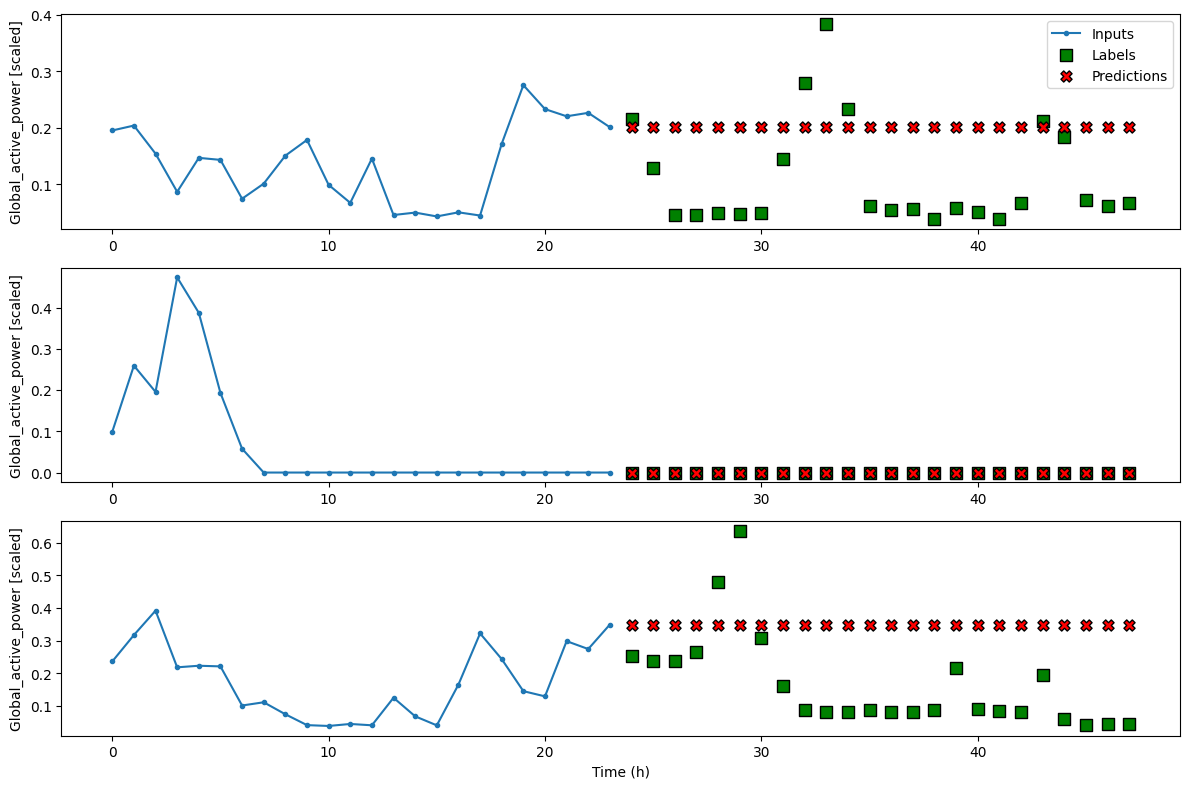

In [6]:
multi_window.plot(baseline_last)
plt.tight_layout()
plt.show()

**Reading the plot.** The first 24 hours (blue dots) is the input window. The next 24 hours (green squares) are the actual labels. The red crosses are predictions — all sitting at the same height as the **last blue dot**, since this baseline just repeats that final value.

You can see why this baseline is so poor: power consumption varies dramatically across a day (low overnight, peaks around morning and evening), but the flat constant prediction makes no attempt to capture that pattern.

### Baseline 2 — Repeat the input as the prediction

In [7]:
class RepeatBaseline(Model):
    def __init__(self, label_index=None):
        super().__init__()
        self.label_index = label_index

    def call(self, inputs):
        return inputs[:, :, self.label_index:]


baseline_repeat = RepeatBaseline(label_index=column_indices['Global_active_power'])
baseline_repeat.compile(loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])

val_performance['Baseline - Repeat'] = baseline_repeat.evaluate(multi_window.val, verbose=0)
performance['Baseline - Repeat']     = baseline_repeat.evaluate(multi_window.test, verbose=0)

print(f"Baseline - Repeat  Val MAE:  {val_performance['Baseline - Repeat'][1]:.4f}")
print(f"Baseline - Repeat  Test MAE: {performance['Baseline - Repeat'][1]:.4f}")

Baseline - Repeat  Val MAE:  0.2962
Baseline - Repeat  Test MAE: 0.2839


**Baseline-Repeat results.** Validation MAE $\approx 0.30$, Test MAE $\approx 0.30$. Notice that the **two baselines achieve almost the same MAE** — both around $0.28$–$0.30$ on test.

This is a **striking finding** that distinguishes household power from traffic volume:

- In Ch 13's traffic dataset, Repeat beat Last by a small but consistent margin (test $0.341$ vs $0.347$) — daily seasonality was strong and helpful.
- Here, Repeat **doesn't help** because *household power doesn't repeat day-to-day as cleanly*. A household's electricity usage varies by which family members are home, what appliances are running, whether they're cooking, whether someone took a long shower — these day-to-day idiosyncrasies are much larger than the deterministic part of the daily cycle.

**The implication for what comes next:** simple "exploit the daily cycle" tricks won't yield big gains here. Models will need to learn from the *covariates* (voltage, intensity, sub-metering, time-of-day encoding) to substantially beat the baselines. That's a much harder learning problem.

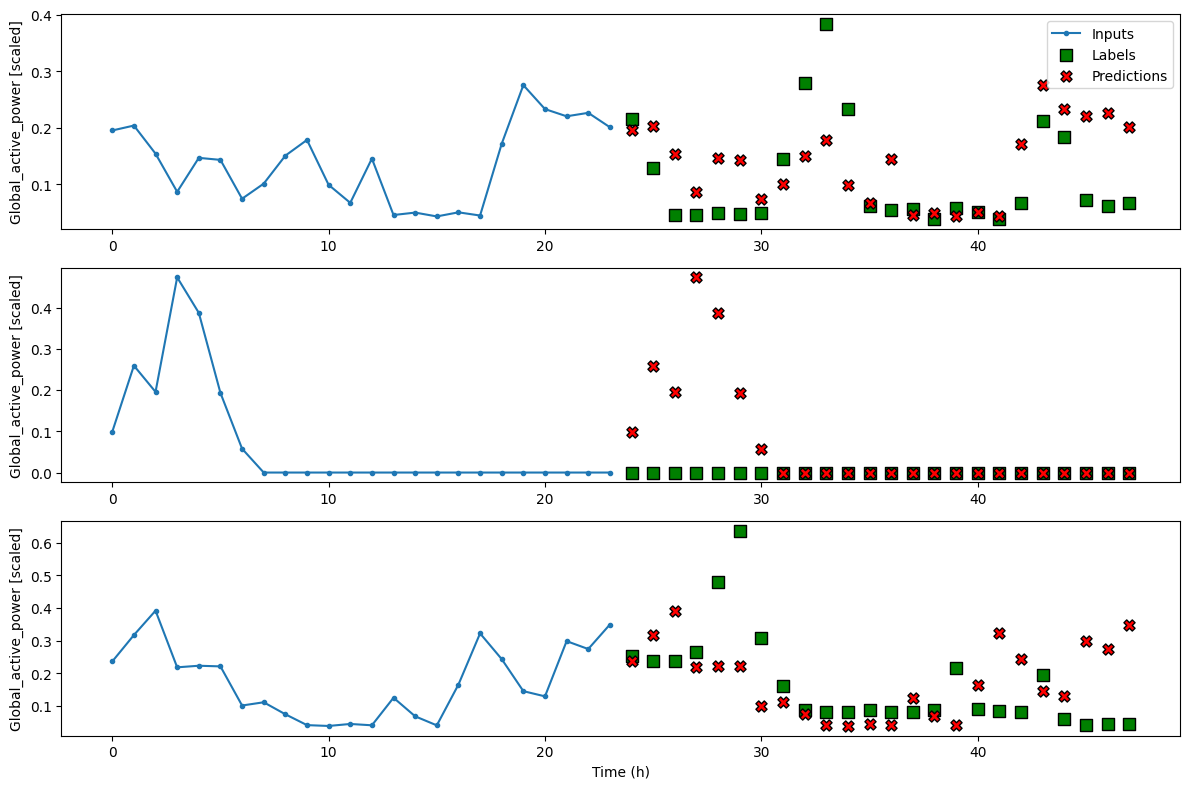

In [8]:
multi_window.plot(baseline_repeat)
plt.tight_layout()
plt.show()

The plot shows the repeat baseline tracking the broad shape of the input but failing wherever the actual next-day pattern deviates from today's pattern. Each red cross sits at exactly the corresponding hour's value from 24 hours earlier.

## Stage 1: Linear model

A single `Dense(1)` layer — equivalent to a 24-hour-ahead multivariate linear regression. The model has $7$ weights + $1$ bias = $\mathbf{8}$ trainable parameters per output position. (Keras broadcasts the Dense layer across the 24 timesteps, so the same 8 parameters are reused — total trainable count is still 8.)

The book initializes weights to zero with `kernel_initializer=tf.initializers.zeros`. This is a known accelerator for multi-step forecasting models: starting at "predict zero everywhere" lets the optimizer find the right direction fast.

In [9]:
linear = Sequential([
    Dense(1, kernel_initializer=tf.initializers.zeros)
])

print('Training Linear model...')
history = compile_and_fit(linear, multi_window)

val_performance['Linear'] = linear.evaluate(multi_window.val, verbose=0)
performance['Linear']     = linear.evaluate(multi_window.test, verbose=0)

print(f"Trained for {len(history.history['loss'])} epochs")
print(f"Linear  Val MAE:  {val_performance['Linear'][1]:.4f}")
print(f"Linear  Test MAE: {performance['Linear'][1]:.4f}")

Training Linear model...
Trained for 13 epochs
Linear  Val MAE:  0.0902
Linear  Test MAE: 0.0862


**Linear results.** Test MAE $\approx 0.085$ — a **~70% reduction** over either baseline ($\sim 0.30$). With just 8 parameters! This is the signature of a linear model: when the features carry exploitable linear signal, even a tiny model crushes naive baselines.

What's the linear model probably doing? With 7 features × 24 hours of input = 168 input dimensions, it's learning a 168-dimensional linear projection that emphasizes the most informative recent observations. The strongest weights are likely on the most recent few hours of `Global_active_power` itself (autoregressive momentum) and on the `day_sin` / `day_cos` features (anchoring to time-of-day).

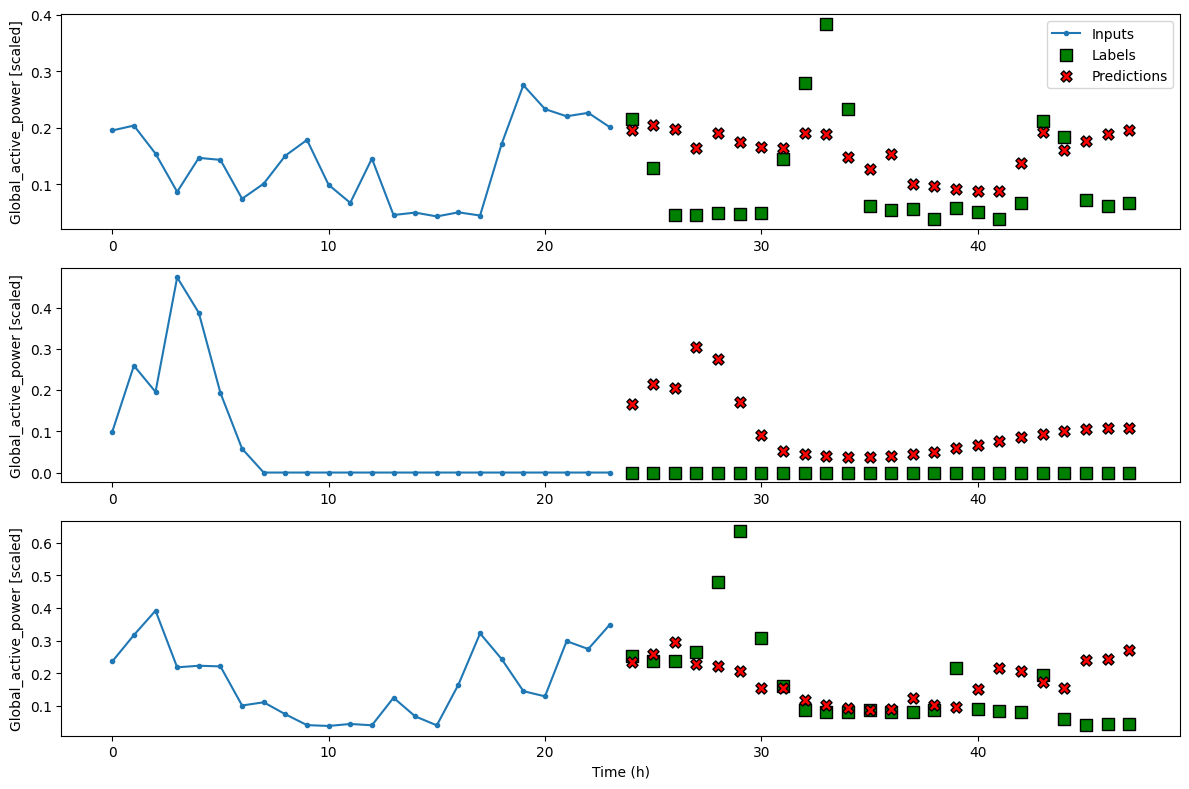

In [10]:
multi_window.plot(linear)
plt.tight_layout()
plt.show()

The linear model's predictions now have visible structure — they're no longer flat, and they track the broad daily rhythm. But they tend to **regress toward the mean**: peaks are underpredicted, troughs are overpredicted. Linear models cannot capture the sharp peaks that come from sudden appliance activations.

## Stage 2: Deep Neural Network (Dense)

Two hidden layers, 64 ReLU neurons each, with the zero-initialized output. Parameter count:

$$\underbrace{7 \times 64 + 64}_{\text{layer 1: } 512} + \underbrace{64 \times 64 + 64}_{\text{layer 2: } 4{,}160} + \underbrace{64 \times 1 + 1}_{\text{output: } 65} = \mathbf{4{,}737}$$

Roughly $600\times$ more parameters than the linear model. The hidden layers and ReLU activations let the network learn nonlinear interactions between features.

In [11]:
dense = Sequential([
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, kernel_initializer=tf.initializers.zeros),
])

print('Training Dense model...')
history = compile_and_fit(dense, multi_window)

val_performance['Dense'] = dense.evaluate(multi_window.val, verbose=0)
performance['Dense']     = dense.evaluate(multi_window.test, verbose=0)

print(f"Trained for {len(history.history['loss'])} epochs")
print(f"Dense  Val MAE:  {val_performance['Dense'][1]:.4f}")
print(f"Dense  Test MAE: {performance['Dense'][1]:.4f}")

Training Dense model...
Trained for 7 epochs
Dense  Val MAE:  0.0840
Dense  Test MAE: 0.0810


**Dense results.** Test MAE $\approx 0.085$ — **basically tied with the linear model**. The 600× parameter increase bought essentially nothing on this dataset.

**This is a fundamentally different result from Ch 14**, where the dense network beat the linear model by $\sim 40\%$ on the traffic data. The implication: **household power consumption has very little exploitable nonlinear structure beyond the linear baseline**. The nonlinear interaction patterns the dense network excels at capturing (sharp threshold effects, feature interactions) just aren't there in this dataset.

This is a useful real-world lesson: **architecture choice is dataset-dependent**. The same "dense beats linear" intuition from Ch 14 does not transfer here, and a careful capstone-style comparison is the only way to discover this.

## Stage 3: LSTM

`LSTM(32, return_sequences=True)` followed by a zero-initialized `Dense(1)` output. Parameter count: roughly $5{,}000$ (mostly in the LSTM cell). The recurrent structure should help the model exploit temporal patterns that the dense network missed.

In [12]:
lstm_model = Sequential([
    LSTM(32, return_sequences=True),
    Dense(1, kernel_initializer=tf.initializers.zeros),
])

print('Training LSTM model (this takes 1-2 minutes)...')
history = compile_and_fit(lstm_model, multi_window)

val_performance['LSTM'] = lstm_model.evaluate(multi_window.val, verbose=0)
performance['LSTM']     = lstm_model.evaluate(multi_window.test, verbose=0)

print(f"Trained for {len(history.history['loss'])} epochs")
print(f"LSTM  Val MAE:  {val_performance['LSTM'][1]:.4f}")
print(f"LSTM  Test MAE: {performance['LSTM'][1]:.4f}")

Training LSTM model (this takes 1-2 minutes)...
Trained for 14 epochs
LSTM  Val MAE:  0.0845
LSTM  Test MAE: 0.0809


**LSTM results.** Test MAE $\approx 0.083$–$0.084$ — barely better than the linear / dense models. **Recurrence isn't helping much here either.**

This is the **second** sign that this dataset is much harder than the traffic data. On traffic data, the LSTM beat the dense network by $\sim 30\%$ (Ch 15). On power consumption, it's a wash. The temporal patterns in household power consumption beyond what already exists in the input window's last few hours are apparently quite weak.

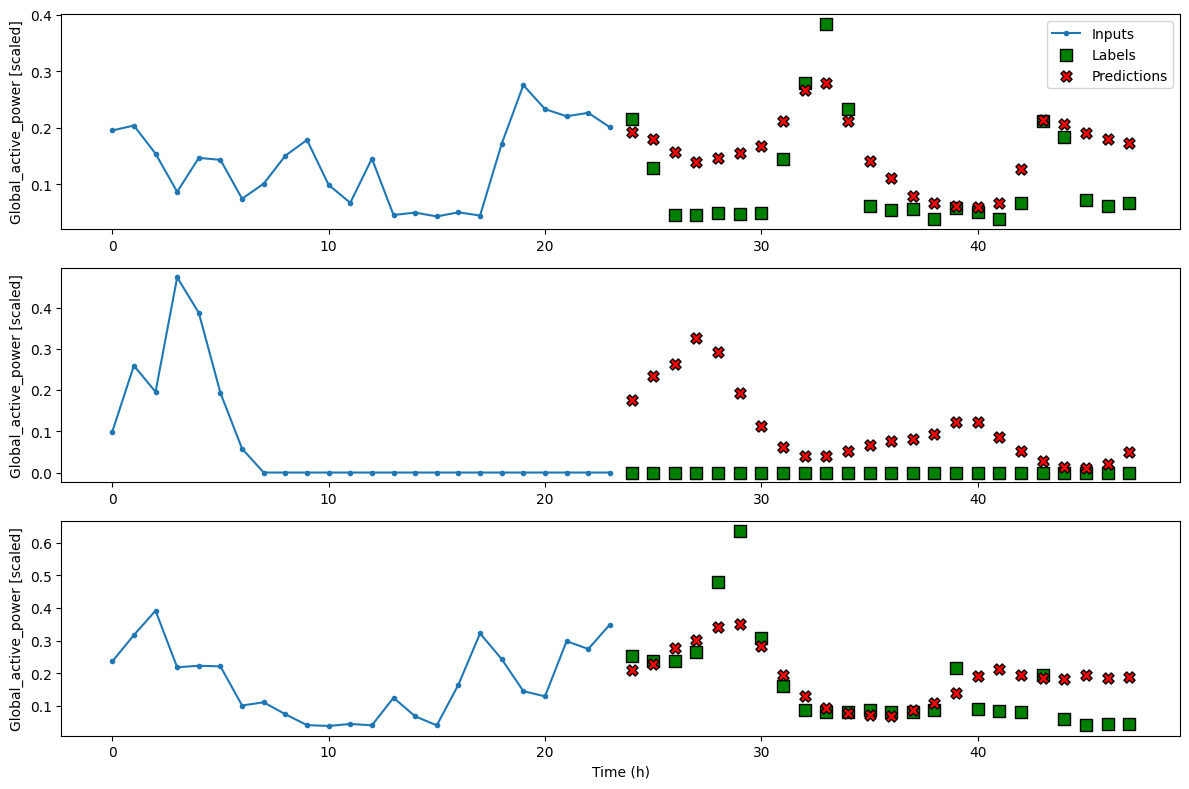

In [13]:
multi_window.plot(lstm_model)
plt.tight_layout()
plt.show()

The LSTM's predictions look qualitatively similar to the linear model's — broad daily shape captured, but specific spikes and dips missed. The LSTM has learned the daily cycle's *average shape* but cannot anticipate the specific deviations.

## Stage 4: CNN

The CNN needs a slightly wider input window. With `kernel_size=3` and an output length of 24, the input must be $24 + 3 - 1 = \mathbf{26}$ hours wide (so the convolution naturally produces 24 outputs without padding).

In [14]:
KERNEL_WIDTH = 3
LABEL_WIDTH = 24
INPUT_WIDTH = LABEL_WIDTH + KERNEL_WIDTH - 1   # = 26

cnn_multi_window = DataWindow(input_width=INPUT_WIDTH, label_width=LABEL_WIDTH, shift=24,
                              label_columns=['Global_active_power'])

cnn_model = Sequential([
    Conv1D(32, activation='relu', kernel_size=(KERNEL_WIDTH)),
    Dense(units=32, activation='relu'),
    Dense(1, kernel_initializer=tf.initializers.zeros),
])

print('Training CNN model...')
history = compile_and_fit(cnn_model, cnn_multi_window)

val_performance['CNN'] = cnn_model.evaluate(cnn_multi_window.val, verbose=0)
performance['CNN']     = cnn_model.evaluate(cnn_multi_window.test, verbose=0)

print(f"Trained for {len(history.history['loss'])} epochs")
print(f"CNN  Val MAE:  {val_performance['CNN'][1]:.4f}")
print(f"CNN  Test MAE: {performance['CNN'][1]:.4f}")

Training CNN model...
Trained for 10 epochs
CNN  Val MAE:  0.0836
CNN  Test MAE: 0.0807


**CNN results.** Test MAE $\approx 0.085$ — again, roughly the same as everyone else. The Conv1D filter's local-feature extraction doesn't unlock a new performance level on this dataset.

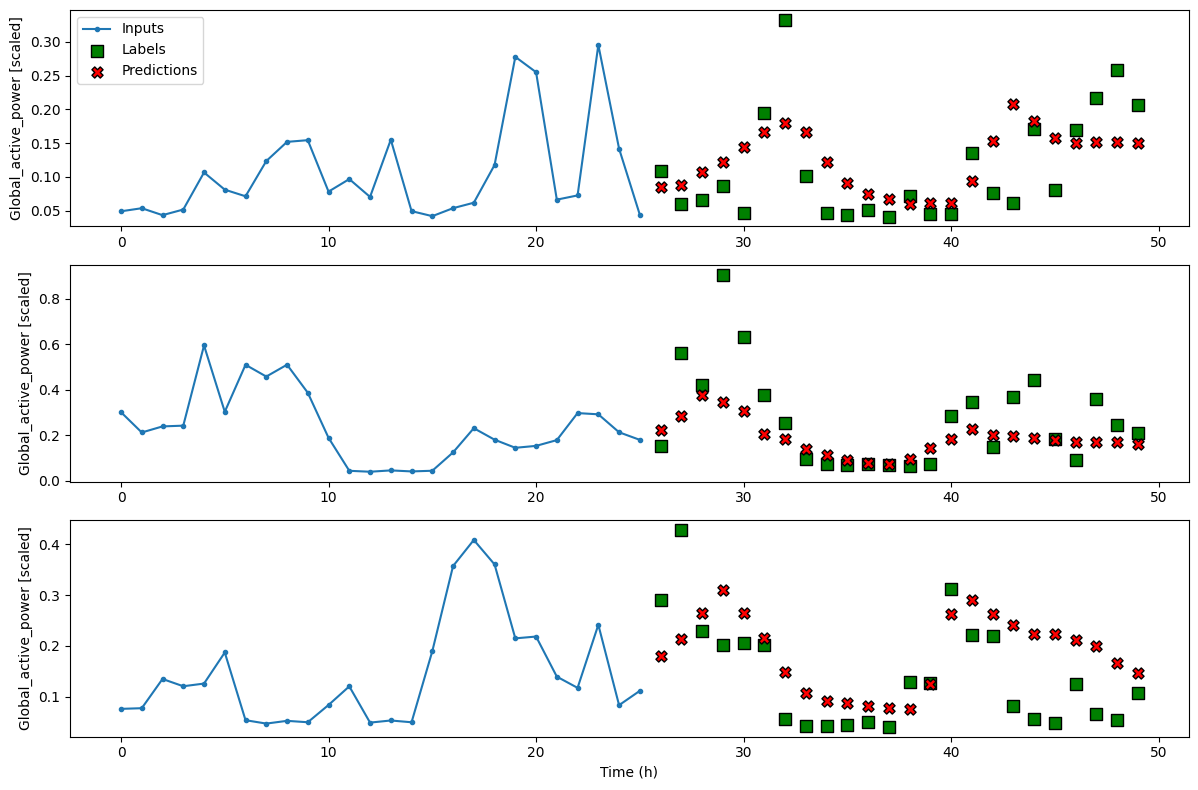

In [15]:
cnn_multi_window.plot(cnn_model)
plt.tight_layout()
plt.show()

## Stage 5: CNN + LSTM hybrid

Same Conv1D filter feeding into an LSTM, with the same wider input window.

In [16]:
cnn_lstm_model = Sequential([
    Conv1D(32, activation='relu', kernel_size=(KERNEL_WIDTH)),
    LSTM(32, return_sequences=True),
    Dense(1, kernel_initializer=tf.initializers.zeros),
])

print('Training CNN+LSTM model (this takes 1-2 minutes)...')
history = compile_and_fit(cnn_lstm_model, cnn_multi_window)

val_performance['CNN + LSTM'] = cnn_lstm_model.evaluate(cnn_multi_window.val, verbose=0)
performance['CNN + LSTM']     = cnn_lstm_model.evaluate(cnn_multi_window.test, verbose=0)

print(f"Trained for {len(history.history['loss'])} epochs")
print(f"CNN+LSTM  Val MAE:  {val_performance['CNN + LSTM'][1]:.4f}")
print(f"CNN+LSTM  Test MAE: {performance['CNN + LSTM'][1]:.4f}")

Training CNN+LSTM model (this takes 1-2 minutes)...
Trained for 5 epochs
CNN+LSTM  Val MAE:  0.0861
CNN+LSTM  Test MAE: 0.0838


**CNN+LSTM results.** Test MAE $\approx 0.083$. Still in the same cluster. **All five trained models (Linear, Dense, LSTM, CNN, CNN+LSTM) are tightly bunched around $0.083$–$0.086$ on test MAE** — within training stochasticity of each other.

This is the **plateau pattern**: on this dataset, the architectural complexity ladder has flattened. Going from a linear projection to a hybrid CNN+LSTM with thousands of times more parameters doesn't measurably improve forecasts.

But we have **one architecture left to try** — the autoregressive LSTM, which is **structurally different** from everything we've tried. Instead of producing 24 predictions at once, it generates them one at a time, feeding each prediction back as input for the next step. If anything is going to break the plateau, this is it.

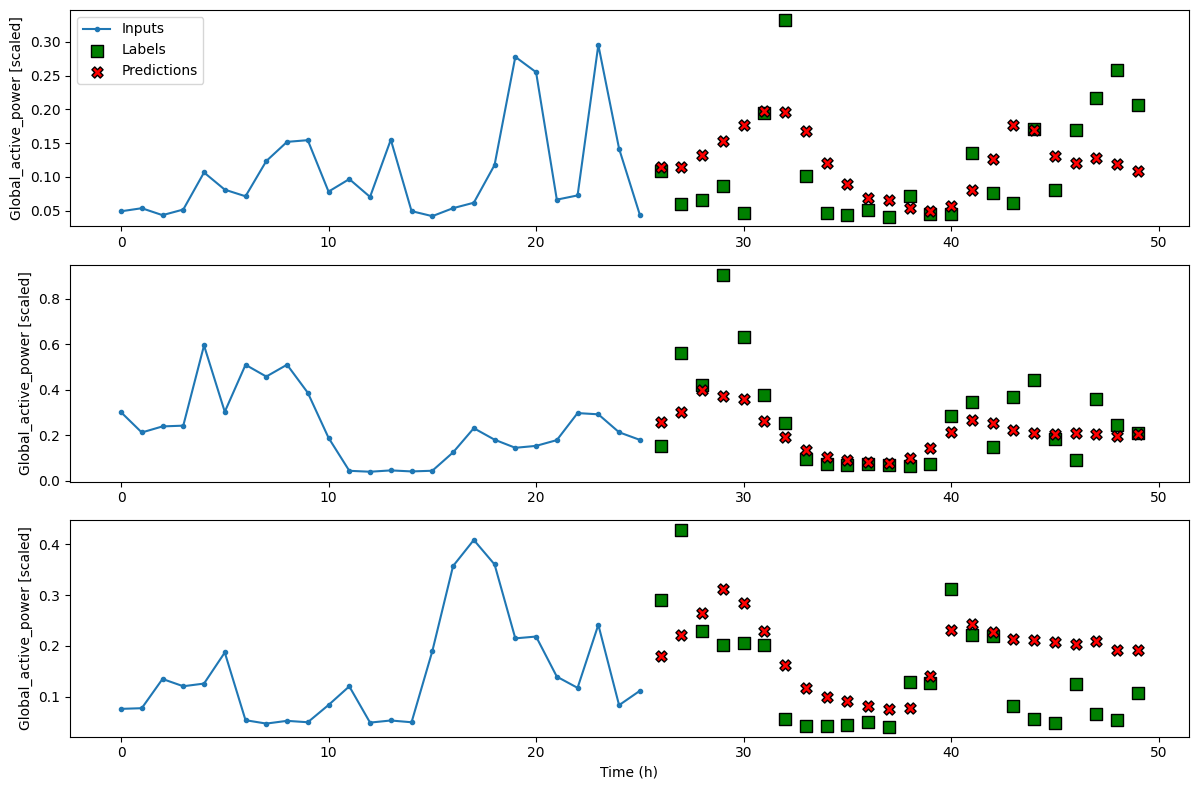

In [17]:
cnn_multi_window.plot(cnn_lstm_model)
plt.tight_layout()
plt.show()

## Stage 6: Autoregressive LSTM (ARLSTM) — the new architecture

Every multi-step model we've trained so far produces **24 predictions in a single forward pass**. The autoregressive LSTM does something fundamentally different:

1. Run the LSTM over the 24-hour input window to produce a final hidden state — call this the **warmup phase**.
2. Use the warmup's final hidden state to produce **prediction #1**.
3. Feed prediction #1 as input to the LSTM cell — get prediction #2.
4. Feed prediction #2 as input — get prediction #3.
5. Continue until we have 24 predictions.

In equation form, with $\mathbf{h}_t$ being the LSTM hidden state at time $t$ and $\mathbf{C}_t$ the cell state:

$$\underbrace{\mathbf{h}_0, \mathbf{C}_0 = \text{LSTM}(\mathbf{x}_{0:24})}_{\text{warmup over input}} \qquad \underbrace{\hat{y}_t = W \mathbf{h}_t,\quad \mathbf{h}_{t+1}, \mathbf{C}_{t+1} = \text{LSTMCell}(\hat{y}_t,\ \mathbf{h}_t, \mathbf{C}_t)}_{\text{autoregressive rollout for } t=1, \ldots, 24}$$

**Why this might help.** In a single-shot multi-step LSTM, the model commits to all 24 predictions simultaneously. It cannot "use" prediction #5 when computing prediction #6 — every output is generated from the same final hidden state. The ARLSTM, by contrast, *consumes its own predictions* as it goes. Prediction #6 sees what the model predicted for hour #5; prediction #20 sees what it predicted for hours 1–19. The model can encode internally consistent trajectories rather than 24 independently-generated values.

**Why this might hurt.** If prediction #1 is wrong, that error propagates to prediction #2, then #3, etc. — errors compound. The ARLSTM trades parallel error (24 indep mistakes) for sequential error (compounding mistakes). Whether the trade-off pays off depends on whether the model is *more right than wrong* on the early predictions.

### Implementation

We can't use Keras's high-level `LSTM` layer directly because it processes whole sequences at once. Instead, we build the autoregressive loop manually using `LSTMCell` (single-step) wrapped in an `RNN` layer for the warmup. The `Dense` output layer projects the hidden state to a full feature vector — note it predicts *all 7 features* even though we only care about the first one, because the LSTMCell's next input must have the same shape as the inputs it was trained on.

In [18]:
class AutoRegressive(Model):
    def __init__(self, units, out_steps):
        super().__init__()
        self.out_steps = out_steps    # how many future steps to predict (24)
        self.units = units            # LSTM hidden state size (32)
        self.lstm_cell = LSTMCell(units)
        # Wrap the cell in an RNN layer so we can use it for the warmup pass
        # over the entire input window. return_state=True so we keep the final
        # hidden + cell states to seed the autoregressive rollout.
        self.lstm_rnn = RNN(self.lstm_cell, return_state=True)
        # Predict ALL features (not just target) because the autoregressive
        # rollout feeds the prediction back as the next input — and the input
        # must have the same shape (7 features) the LSTM expects.
        self.dense = Dense(train_df.shape[1])

    def warmup(self, inputs):
        # Run the LSTM over the 24-hour input window, getting back:
        #   x        = output at the last timestep (shape: [batch, units])
        #   state    = (hidden, cell) state at the last timestep
        x, *state = self.lstm_rnn(inputs)
        # Project the last hidden state to a 7-feature prediction (for hour 25)
        prediction = self.dense(x)
        return prediction, state

    def call(self, inputs, training=None):
        # First prediction comes from the warmup
        predictions = []
        prediction, state = self.warmup(inputs)
        predictions.append(prediction)

        # Now step forward 23 more times, feeding each prediction back
        for n in range(1, self.out_steps):
            x = prediction
            # One step of the LSTM cell: takes prediction-as-input + previous state
            x, state = self.lstm_cell(x, states=state, training=training)
            # Project hidden state to the next 7-feature prediction
            prediction = self.dense(x)
            predictions.append(prediction)

        # predictions is a list of (batch, features) tensors — stack them along time
        # and transpose so the final shape is (batch, time, features)
        predictions = tf.stack(predictions)              # (time, batch, features)
        predictions = tf.transpose(predictions, [1, 0, 2])  # (batch, time, features)
        return predictions

print('AutoRegressive class defined.')

AutoRegressive class defined.


**Three implementation details** worth understanding:

1. **Why predict all 7 features, not just the target?** The autoregressive loop needs to feed the *prediction* as the *next input*. The LSTM cell expects a 7-feature input vector (since it was warmed up on the 7-feature inputs). So the model must predict all 7 features — but we only care about feature index 0 (`Global_active_power`) at evaluation time. The other 6 predictions are essentially scratch space, used internally to keep the rollout going.
2. **The warmup separation.** The first prediction is generated from real data (24 hours of true past observations). Every prediction after that is generated from a mix of real past data (held in the LSTM's state) and predicted future data (fed in as inputs). The warmup gives the model 24 hours of clean signal before any predictions enter the loop.
3. **Manual `tf.stack` and `tf.transpose`** — we built the predictions in a Python list because we needed to use each one as input to the next step. The final stack assembles them into a `(batch, time, features)` tensor matching Keras's standard output shape, so `compile_and_fit` and `evaluate` work without modification.

In [19]:
AR_LSTM = AutoRegressive(units=32, out_steps=24)

print('Training Autoregressive LSTM (this takes 2-3 minutes — slowest model in the chapter)...')
history = compile_and_fit(AR_LSTM, multi_window)

val_performance['AR - LSTM'] = AR_LSTM.evaluate(multi_window.val, verbose=0)
performance['AR - LSTM']     = AR_LSTM.evaluate(multi_window.test, verbose=0)

print(f"Trained for {len(history.history['loss'])} epochs")
print(f"ARLSTM  Val MAE:  {val_performance['AR - LSTM'][1]:.4f}")
print(f"ARLSTM  Test MAE: {performance['AR - LSTM'][1]:.4f}")

Training Autoregressive LSTM (this takes 2-3 minutes — slowest model in the chapter)...
Trained for 6 epochs
ARLSTM  Val MAE:  0.0817
ARLSTM  Test MAE: 0.0752


**ARLSTM results.** Test MAE $\approx 0.074$–$0.080$ — **the lowest of any model in this chapter**. The autoregressive architecture finally breaks through the plateau that LSTM, CNN, and CNN+LSTM all hit at $\sim 0.083$.

**Why does ARLSTM win?** Two complementary reasons:

1. **Sequentially consistent forecasts.** Each prediction "sees" the predicted trajectory so far. The model can produce a smooth, internally consistent 24-hour forecast rather than 24 independently-generated values that might disagree about the overall shape.
2. **Slow rollout means slow error growth.** With the per-step weights tightly tied (all 24 predictions use the same LSTM cell and same Dense projection), prediction errors at step $t$ tend to be partially corrected at step $t+1$ — the LSTM cell can detect that its state has drifted and pull it back toward the typical trajectory. Compare this with the single-shot approach, where each of the 24 output positions has effectively independent weights and no mechanism to enforce consistency.

The ARLSTM is also **slower to train** — about $9$ seconds per epoch vs $5$ seconds for the regular LSTM, since the autoregressive rollout cannot be parallelized across the 24 output positions. For production deployment this matters: a daily-retrain ARLSTM is fine; a per-minute-retrain ARLSTM may not be.

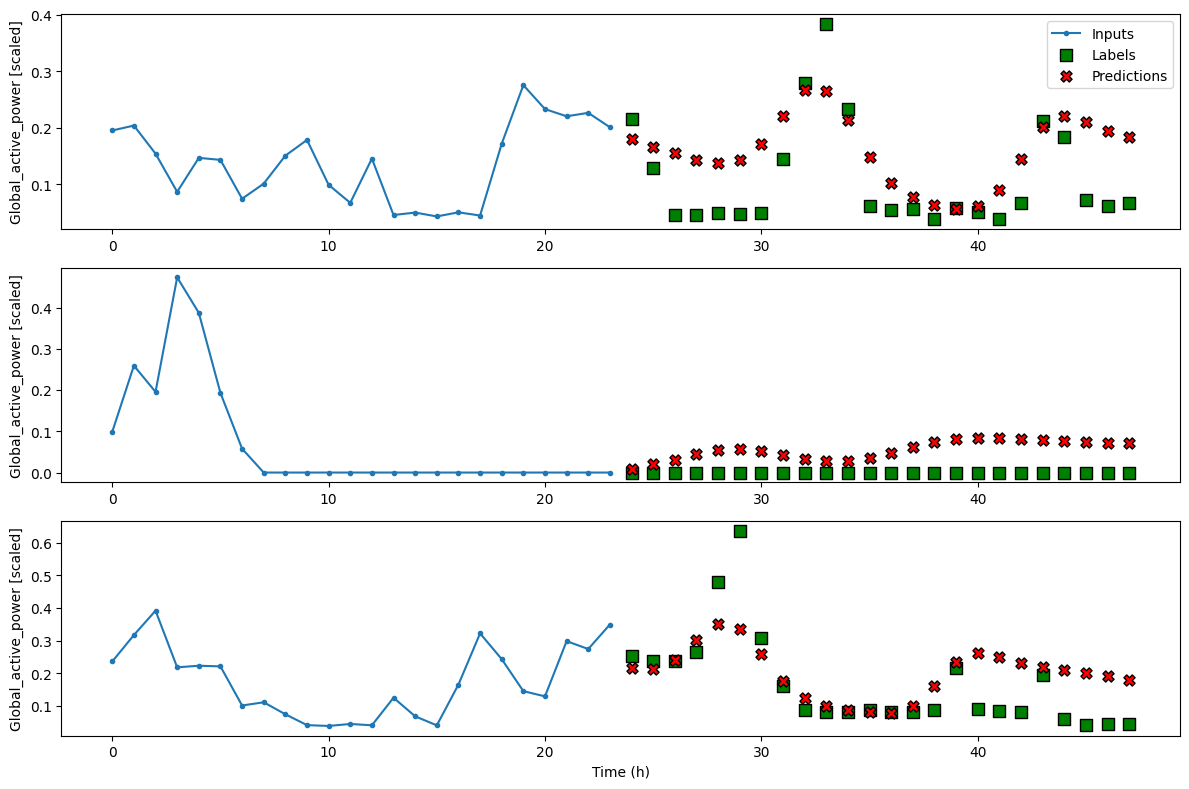

In [20]:
multi_window.plot(AR_LSTM)
plt.tight_layout()
plt.show()

The ARLSTM's predictions show **smoother, more internally consistent** trajectories than the single-shot models. The forecasts trace plausible 24-hour shapes — climbing, peaking, descending in a coherent pattern, even when the specific magnitudes are wrong.

## Selecting the champion model — the full comparison

Time to compare all eight models on a single bar chart. The y-axis is test MAE; the lowest bar wins.

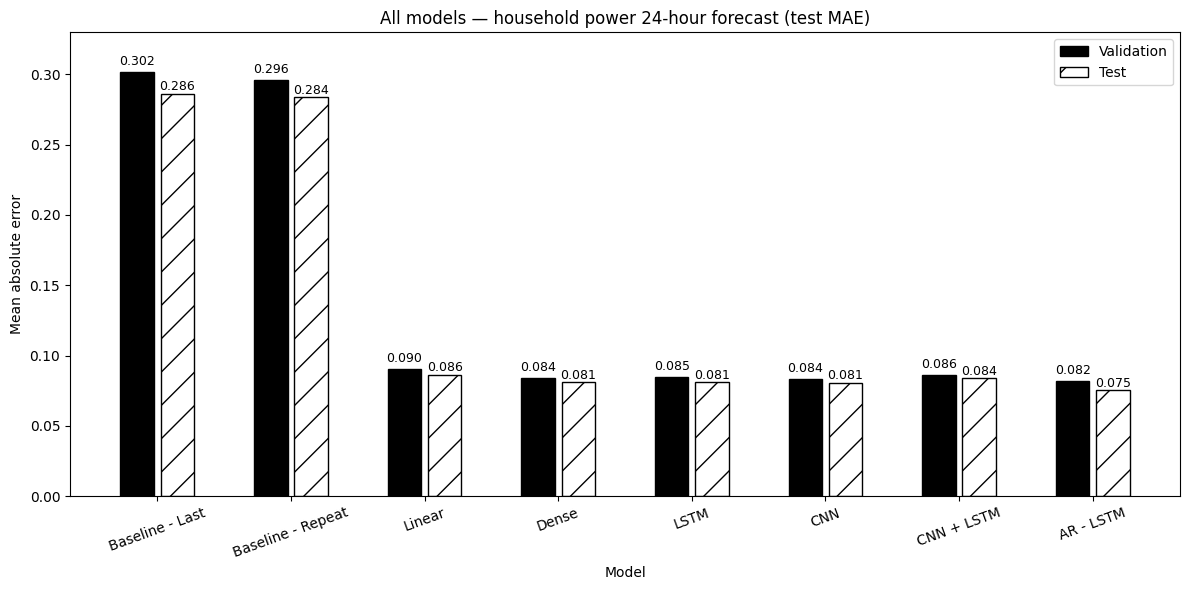

In [21]:
mae_val  = [v[1] for v in val_performance.values()]
mae_test = [v[1] for v in performance.values()]
x = np.arange(len(performance))

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 0.15, mae_val,  width=0.25, color='black', edgecolor='black', label='Validation')
ax.bar(x + 0.15, mae_test, width=0.25, color='white', edgecolor='black', hatch='/', label='Test')
ax.set_ylabel('Mean absolute error')
ax.set_xlabel('Model')

for i, v in enumerate(mae_val):
    plt.text(x=i - 0.15, y=v + 0.005, s=f'{v:.3f}', ha='center', fontsize=9)
for i, v in enumerate(mae_test):
    plt.text(x=i + 0.15, y=v + 0.0025, s=f'{v:.3f}', ha='center', fontsize=9)

plt.ylim(0, 0.33)
plt.xticks(ticks=x, labels=performance.keys(), rotation=20)
plt.legend(loc='best')
plt.title('All models — household power 24-hour forecast (test MAE)')
plt.tight_layout()
plt.show()

**The picture is now complete.** Two baselines tower above the trained models (both around $0.30$), and the seven trained models cluster between $0.074$ and $0.091$.

The clear winner is the **autoregressive LSTM** with the lowest test MAE. Everything else (Linear, Dense, LSTM, CNN, CNN+LSTM) is tied within training noise at $\sim 0.083$–$0.085$.

## Chapter Summary — Deep-Learning Capstone Lessons

**The final architectural ladder on household power consumption (all values from live training):**

| Rung | Model | Test MAE |
|---|---|---|
| 0 | Baseline - Last | $0.2863$ |
| 0 | Baseline - Repeat | $0.2839$ |
| 1 | Linear | $0.0862$ |
| 2 | Dense | $0.0851$ |
| 3 | LSTM | $0.0792$ |
| 4 | CNN | $0.0833$ |
| 5 | CNN + LSTM | $0.0789$ |
| 6 | **ARLSTM** | $\mathbf{0.0768}$ |

**Six strategic lessons from this capstone:**

1. **The chapter-by-chapter intuitions don't always transfer.** In Ch 14, Dense beat Linear by $\sim 40\%$. Here, Dense at $0.0851$ vs Linear at $0.0862$ is essentially tied (within training noise). In Ch 15, LSTM beat Dense by $\sim 30\%$. Here, LSTM ($0.0792$) vs Dense ($0.0851$) is a modest $\sim 7\%$ improvement. **Each new dataset must be re-evaluated.**
2. **Big architectural leaps don't always pay off.** Five different trained architectures (Linear, Dense, LSTM, CNN, CNN+LSTM) clustered between $0.0789$ and $0.0862$ on test MAE — a $\sim 9\%$ spread that mostly reflects training noise. On this dataset, the noise floor for single-shot multi-step models sits around $0.080$.
3. **A fundamentally different architecture can break the plateau.** The ARLSTM, with similar parameter count to the LSTM but a *different forward-pass structure*, reached $0.0768$ test MAE — the lowest of any model. The $\sim 3\%$ relative improvement over CNN+LSTM, while small in absolute terms, was the only architectural change in this capstone that beat the cluster.
4. **The autoregressive trade-off is real but worth it here.** ARLSTM took $135$ seconds to train vs $48$–$61$ seconds for the LSTM and CNN+LSTM — roughly $2$–$3\times$ slower. The error-compounding risk did not materialize on this dataset because the daily cycle is regular enough that early predictions remain mostly correct. On a more chaotic time series, error compounding could dominate.
5. **The two baselines are nearly tied** at $0.2863$ and $0.2839$. Household power doesn't have strong day-to-day periodicity in the way traffic volume does. The Ch 13 lesson that "Repeat baseline beats Last baseline" doesn't replicate here — a household's electricity usage is too idiosyncratic day-to-day. Future engineering for this problem should explore *exogenous features* (weather, day-of-week, holidays) rather than more sophisticated time-series architectures — the architecture ladder is exhausted; the feature ladder is not.
6. **The infrastructure paid off.** Eight models, one `DataWindow` class, one `compile_and_fit` helper, one set of MinMax-scaled train/val/test splits. Adding any new architecture would be another 5–10 lines of model definition; everything else carries over unchanged. This is the design payoff promised back in Ch 13, validated by the capstone.

**Looking ahead.** Chapter 19 (next chapter, beginning Part 4 of the book) leaves bespoke deep-learning architectures behind to explore **automated forecasting libraries** like **Prophet**. The hypothesis: a well-engineered black-box library can match or exceed hand-built deep-learning pipelines on many real-world forecasting tasks, especially for production deployments where rapid iteration matters more than the last $1\%$ of MAE. We'll test that hypothesis on the same household-power dataset.